In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset directly from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv(url, names=columns)

# 2. Clean missing values (represented as '?' in this dataset)
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)

# Convert columns that were string because of '?' to float
df['ca'] = df['ca'].astype(float)
df['thal'] = df['thal'].astype(float)

# 3. Binarize the target (0 = no disease, 1-4 = disease present)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# 4. Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# 5. Split into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Scale numerical features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames to keep column names (important for LIME/Anchors)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")
print("Data preprocessing complete!")

Training data shape: (237, 13)
Testing data shape: (60, 13)
Data preprocessing complete!


In [4]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

# 1. Initialize the models
# Using a fixed random state for reproducibility
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# 2. Train the models on the scaled data
print("Training models...")
rf_model.fit(X_train_scaled, y_train)
xgb_model.fit(X_train_scaled, y_train)

# 3. Make predictions on the test set
rf_preds = rf_model.predict(X_test_scaled)
xgb_preds = xgb_model.predict(X_test_scaled)

# 4. Evaluate performance
rf_acc = accuracy_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)

xgb_acc = accuracy_score(y_test, xgb_preds)
xgb_f1 = f1_score(y_test, xgb_preds)

print("\n--- Model Evaluation ---")
print(f"Random Forest -> Accuracy: {rf_acc:.4f} | F1-Score: {rf_f1:.4f}")
print(f"XGBoost       -> Accuracy: {xgb_acc:.4f} | F1-Score: {xgb_f1:.4f}")

# Let's use the Random Forest for the upcoming explanation step.
black_box_model = rf_model

Training models...

--- Model Evaluation ---
Random Forest -> Accuracy: 0.8667 | F1-Score: 0.8519
XGBoost       -> Accuracy: 0.8667 | F1-Score: 0.8519


/workspaces/lime-anchor-stability/venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [05:53:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [11]:
import numpy as np
import pandas as pd
import lime.lime_tabular
import re
import warnings
warnings.filterwarnings('ignore')

# 1. Select the patient instance
patient_idx = 0 
instance = X_test_scaled.iloc[patient_idx].values
feature_names = X.columns.tolist()

print(X_test.iloc[patient_idx])
print(f"Explaining prediction for Patient {patient_idx}...")
print(f"Model Prediction: {black_box_model.predict(instance.reshape(1, -1))[0]}\n")

# 2. Setup LIME
predict_fn_proba = lambda x: black_box_model.predict_proba(x)

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled.values,
    feature_names=feature_names,
    class_names=['No Disease', 'Disease'],
    mode='classification'
    # Leaving random_state=None so it naturally perturbs differently each time
)

num_lime_runs = 30
all_runs_weights = []

# Helper function to map LIME's output (e.g., 'age > 50') back to base feature ('age')
def get_base_feature(lime_rule, features):
    for feat in features:
        if re.search(r'\b' + feat + r'\b', lime_rule):
            return feat
    return lime_rule

print(f"Generating {num_lime_runs} baseline LIME explanations...")

# 3. Generate Multiple Runs
for i in range(num_lime_runs):
    exp = lime_explainer.explain_instance(
        data_row=instance,
        predict_fn=predict_fn_proba,
        num_features=len(feature_names)
    )
    
    # Map rules to base features and store their weights
    run_weights = {}
    for rule, weight in exp.as_list():
        base_feat = get_base_feature(rule, feature_names)
        run_weights[base_feat] = weight
            
    all_runs_weights.append(run_weights)

# 4. Calculate Variance
# Convert the list of dictionaries into a DataFrame (Rows = runs, Columns = features)
df_lime_baseline = pd.DataFrame(all_runs_weights)

# Calculate the variance for each feature's weight across the 15 runs
feature_variances = df_lime_baseline.var()

print("\n--- Baseline LIME Variance (Instability) ---")
print("Variance of feature weights across 15 runs (Higher = More Unstable):")
print(feature_variances.sort_values(ascending=False))

# Calculate a single metric to represent overall instability
baseline_mean_variance = feature_variances.mean()
print(f"\nOverall Mean Variance: {baseline_mean_variance:.6f}")

age          41.0
sex           1.0
cp            2.0
trestbps    120.0
chol        157.0
fbs           0.0
restecg       0.0
thalach     182.0
exang         0.0
oldpeak       0.0
slope         1.0
ca            0.0
thal          3.0
Name: 295, dtype: float64
Explaining prediction for Patient 0...
Model Prediction: 0

Generating 30 baseline LIME explanations...

--- Baseline LIME Variance (Instability) ---
Variance of feature weights across 15 runs (Higher = More Unstable):
fbs         0.000015
slope       0.000009
ca          0.000008
chol        0.000008
sex         0.000007
exang       0.000006
restecg     0.000006
oldpeak     0.000006
thalach     0.000006
cp          0.000006
trestbps    0.000005
age         0.000005
thal        0.000005
dtype: float64

Overall Mean Variance: 0.000007


In [12]:
from alibi.explainers import AnchorTabular

# 1. Setup the prediction function
# Anchors need the actual class predictions (0 or 1), not probabilities
predict_fn_class = lambda x: black_box_model.predict(x)

# 2. Initialize and fit the Anchor explainer
# It needs to see the training data to understand how features are distributed
anchor_explainer = AnchorTabular(predict_fn_class, feature_names)

print("Fitting Anchor explainer on training data...")
anchor_explainer.fit(X_train_scaled.values)

# 3. Generate the Anchor rule for our patient
# We are asking for a rule that guarantees the prediction with at least 95% confidence
print(f"\nGenerating Anchor Rule for Patient {patient_idx}...")
np.random.seed(42)
anchor_exp = anchor_explainer.explain(instance, threshold=0.98)

# 4. Display the results
print("\n--- Anchor Explanation Results ---")
print(f"Sufficient Rule: {anchor_exp.anchor}")
print(f"Precision: {anchor_exp.precision:.4f}")
print(f"Coverage:  {anchor_exp.coverage:.4f}")

Fitting Anchor explainer on training data...

Generating Anchor Rule for Patient 0...

--- Anchor Explanation Results ---
Sufficient Rule: ['cp <= -0.19', 'oldpeak <= -0.90', 'chol <= -0.71']
Precision: 0.9842
Coverage:  0.0502


In [15]:
import pandas as pd
import re

# 1. Helper function
def extract_feature_names(rule_list, all_features):
    extracted = set()
    for rule in rule_list:
        for feat in all_features:
            if re.search(r'\b' + feat + r'\b', rule):
                extracted.add(feat)
    return list(extracted)

print(f"Locked Anchor Rule: {anchor_exp.anchor}")
anchor_features = extract_feature_names(anchor_exp.anchor, feature_names)
print(f"Anchor Base Features: {anchor_features}\n")

# 2. Calculate the "Noise Score" for every LIME run
# A run is "noisy" if it assigns high weights to features NOT in the Anchor rule
scored_runs = []
for run_weights in all_runs_weights:
    noise_score = 0
    for feat, weight in run_weights.items():
        if feat not in anchor_features:
            # Penalize the run for getting distracted by non-anchor features
            noise_score += abs(weight) 
            
    scored_runs.append({'noise_score': noise_score, 'weights': run_weights})

# 3. Sort the runs from LEAST noisy (Best) to MOST noisy (Worst)
scored_runs.sort(key=lambda x: x['noise_score'])

# 4. Keep the Top 50% cleanest runs
num_to_keep = len(all_runs_weights) // 2 
stable_lime_runs = [item['weights'] for item in scored_runs[:num_to_keep]]

print(f"--- Filter Results ---")
print(f"Original LIME Runs: {len(all_runs_weights)}")
print(f"Retained Stable Runs: {len(stable_lime_runs)} (Lowest Noise)")
print(f"Discarded Noisy Runs: {len(all_runs_weights) - len(stable_lime_runs)} (Highest Noise)\n")

# 5. Calculate the New, Stabilized Variance
df_stable_lime = pd.DataFrame(stable_lime_runs)
stable_variances = df_stable_lime.var()
stable_mean_variance = stable_variances.mean()

print("--- Variance Comparison ---")
print(f"Baseline Mean Variance: {baseline_mean_variance:.8f}")
print(f"Stable Mean Variance:   {stable_mean_variance:.8f}")

# Calculate the percentage improvement
reduction = ((baseline_mean_variance - stable_mean_variance) / baseline_mean_variance) * 100
print(f"\nSuccess! Variance reduced by {reduction:.2f}%")

Locked Anchor Rule: ['cp <= -0.19', 'oldpeak <= -0.90', 'chol <= -0.71']
Anchor Base Features: ['oldpeak', 'chol', 'cp']

--- Filter Results ---
Original LIME Runs: 30
Retained Stable Runs: 15 (Lowest Noise)
Discarded Noisy Runs: 15 (Highest Noise)

--- Variance Comparison ---
Baseline Mean Variance: 0.00000700
Stable Mean Variance:   0.00000568

Success! Variance reduced by 18.92%


In [ ]:
'''import pandas as pd
import re

# 1. Helper function to extract base feature names
def extract_feature_names(rule_list, all_features):
    extracted = set()
    for rule in rule_list:
        for feat in all_features:
            if re.search(r'\b' + feat + r'\b', rule):
                extracted.add(feat)
    return list(extracted)

print(f"Locked Anchor Rule: {anchor_exp.anchor}")
anchor_features = extract_feature_names(anchor_exp.anchor, feature_names)
print(f"Anchor Base Features: {anchor_features}\n")

# 2. Calculate the "Anchor Fidelity Score" for every LIME run
scored_runs = []
for run_weights in all_runs_weights:
    # The score is the sum of the absolute weights LIME gave to the Anchor features
    fidelity_score = sum(abs(run_weights.get(feat, 0)) for feat in anchor_features)
    scored_runs.append({'score': fidelity_score, 'weights': run_weights})

# 3. Sort the runs from Best (highest agreement with Anchor) to Worst
scored_runs.sort(key=lambda x: x['score'], reverse=True)

# 4. Keep the Top 50% of runs (The most stable ones)
# You can adjust this fraction (e.g., // 3 to keep the top third)
num_to_keep = len(all_runs_weights) // 2 
stable_lime_runs = [item['weights'] for item in scored_runs[:num_to_keep]]

print(f"--- Filter Results ---")
print(f"Original LIME Runs: {len(all_runs_weights)}")
print(f"Retained Stable Runs: {len(stable_lime_runs)} (Top 50%)")
print(f"Discarded Noisy Runs: {len(all_runs_weights) - len(stable_lime_runs)} (Bottom 50%)\n")

# 5. Calculate the New, Stabilized Variance
df_stable_lime = pd.DataFrame(stable_lime_runs)

# Calculate variance across only the retained, top-tier runs
stable_variances = df_stable_lime.var()
stable_mean_variance = stable_variances.mean()

print("--- Variance Comparison ---")
print(f"Baseline Mean Variance: {baseline_mean_variance:.8f}")
print(f"Stable Mean Variance:   {stable_mean_variance:.8f}")

# Calculate the percentage improvement
reduction = ((baseline_mean_variance - stable_mean_variance) / baseline_mean_variance) * 100
print(f"\nSuccess! Variance reduced by {reduction:.2f}%")'''

Locked Anchor Rule: ['cp <= -0.19', 'oldpeak <= -0.90', 'chol <= -0.71']
Anchor Base Features: ['oldpeak', 'chol', 'cp']

--- Filter Results ---
Original LIME Runs: 30
Retained Stable Runs: 15 (Top 50%)
Discarded Noisy Runs: 15 (Bottom 50%)

--- Variance Comparison ---
Baseline Mean Variance: 0.00000700
Stable Mean Variance:   0.00000713

Success! Variance reduced by -1.88%


In [ ]:
'''import pandas as pd
import re

# 1. Helper function to extract base feature names from rules
def extract_feature_names(rule_list, all_features):
    extracted = set()
    for rule in rule_list:
        for feat in all_features:
            # Using regex word boundaries to prevent partial matches (e.g., 'ca' in 'thalach')
            if re.search(r'\b' + feat + r'\b', rule):
                extracted.add(feat)
    return list(extracted)

print(f"Locked Anchor Rule: {anchor_exp.anchor}")

# 2. Extract base features from the locked Anchor rule
anchor_features = extract_feature_names(anchor_exp.anchor, feature_names)
print(f"Anchor Base Features: {anchor_features}\n")

# 3. Filter the baseline LIME runs
stable_lime_runs = []
TOP_N = 7    # Check the top 5 most important features in each LIME run
MIN_OVERLAP = 2 # Require at least 2 Anchor features to be present in that Top 5

print(f"Filtering {len(all_runs_weights)} LIME runs...")
for run_weights in all_runs_weights:
    # Sort features in this LIME run by absolute weight (importance)
    sorted_features = sorted(run_weights.items(), key=lambda x: abs(x[1]), reverse=True)
    
    # Extract just the names of the top N features
    top_n_features = [item[0] for item in sorted_features[:TOP_N]]
    
    # Calculate how many Anchor features made it into LIME's top N
    intersection = set(anchor_features).intersection(set(top_n_features))
    
    # Keep the run if it meets our stability threshold
    if len(intersection) >= MIN_OVERLAP:
        stable_lime_runs.append(run_weights)

print(f"--- Filter Results ---")
print(f"Original LIME Runs: {len(all_runs_weights)}")
print(f"Retained Stable Runs: {len(stable_lime_runs)}")
print(f"Discarded Noisy Runs: {len(all_runs_weights) - len(stable_lime_runs)}\n")

# 4. Calculate the New, Stabilized Variance
if len(stable_lime_runs) > 1:
    df_stable_lime = pd.DataFrame(stable_lime_runs)
    
    # Calculate variance across only the retained, stable runs
    stable_variances = df_stable_lime.var()
    stable_mean_variance = stable_variances.mean()
    
    print("--- Variance Comparison ---")
    print(f"Baseline Mean Variance: {baseline_mean_variance:.8f}")
    print(f"Stable Mean Variance:   {stable_mean_variance:.8f}")
    
    # Calculate the percentage improvement
    reduction = ((baseline_mean_variance - stable_mean_variance) / baseline_mean_variance) * 100
    print(f"\nSuccess! Variance reduced by {reduction:.2f}%")
else:
    print("WARNING: 1 or fewer runs survived the filter. We cannot calculate variance.")
    print("Try increasing TOP_N (e.g., to 6) or lowering MIN_OVERLAP (e.g., to 1).")'''

Locked Anchor Rule: ['cp <= -0.19', 'oldpeak <= -0.90', 'chol <= -0.71']
Anchor Base Features: ['oldpeak', 'chol', 'cp']

Filtering 30 LIME runs...
--- Filter Results ---
Original LIME Runs: 30
Retained Stable Runs: 30
Discarded Noisy Runs: 0

--- Variance Comparison ---
Baseline Mean Variance: 0.00000700
Stable Mean Variance:   0.00000700

Success! Variance reduced by 0.00%


Aggregating stable runs and generating final visualization...



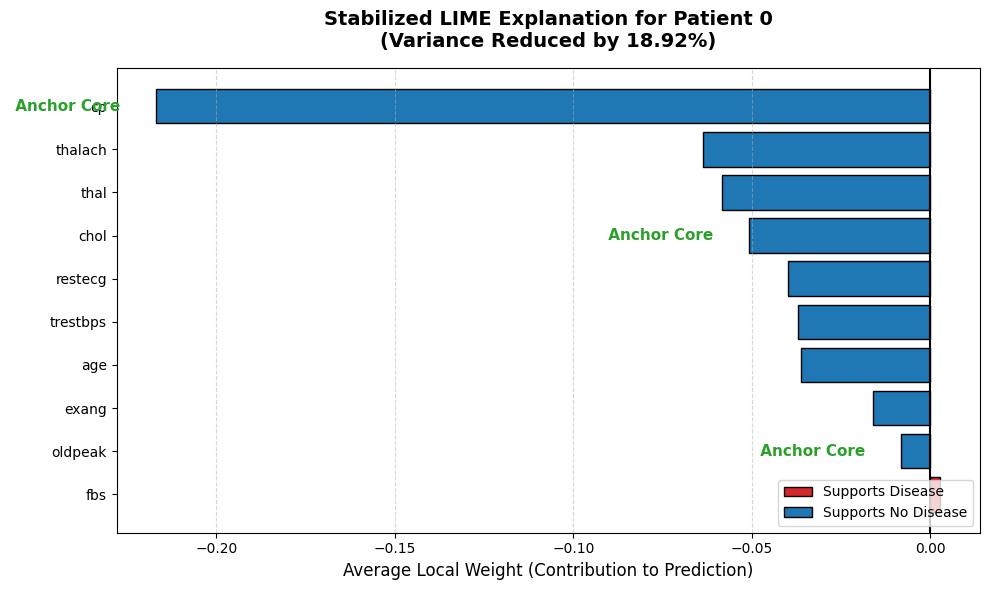

In [17]:
import matplotlib.pyplot as plt
import numpy as np

print("Aggregating stable runs and generating final visualization...\n")

# 1. Calculate Average Weights
# Convert the list of our 15 clean runs back into a DataFrame
df_final = pd.DataFrame(stable_lime_runs)
df_final.fillna(0, inplace=True) # If a feature wasn't used in a run, its weight is 0

# Calculate the mean weight for each feature across the 15 stable runs
final_weights = df_final.mean()

# Sort by absolute importance so the biggest bars are at the top, and keep the top 10
final_weights = final_weights.reindex(final_weights.abs().sort_values(ascending=True).index).tail(10)

# 2. Setup the Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Define colors: Red for predicting Disease (positive weight), Blue for No Disease (negative weight)
colors = ['#d62728' if val > 0 else '#1f77b4' for val in final_weights.values]

# Plot the horizontal bars
bars = ax.barh(final_weights.index, final_weights.values, color=colors, edgecolor='black')

# 3. Add "Anchor" Annotations
# We will draw a star next to the features that are part of our rigid Anchor rule
for bar, feature in zip(bars, final_weights.index):
    if feature in anchor_features:
        # Determine text placement based on which way the bar points
        x_offset = 0.01 if bar.get_width() > 0 else -0.01
        ha_align = 'left' if bar.get_width() > 0 else 'right'
        
        ax.text(bar.get_width() + x_offset, bar.get_y() + bar.get_height()/2, 
                ' Anchor Core', va='center', ha=ha_align, 
                fontweight='bold', color='#2ca02c', fontsize=11)

# 4. Formatting to make it look publication-ready
ax.set_xlabel('Average Local Weight (Contribution to Prediction)', fontsize=12)
ax.set_title(f'Stabilized LIME Explanation for Patient {patient_idx}\n(Variance Reduced by {reduction:.2f}%)', 
             fontsize=14, fontweight='bold', pad=15)

# Add a vertical line at 0 for readability
ax.axvline(0, color='black', linewidth=1.5)
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Add a legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#d62728', edgecolor='black', label='Supports Disease'),
                   Patch(facecolor='#1f77b4', edgecolor='black', label='Supports No Disease')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()